<a href="https://colab.research.google.com/github/mikeshawcode/Mike-Shaw-Data-Analytics-Portfolio/blob/main/FitBit_Data_Analysis_v2_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FitBit Activity Analysis — SQL + Python
**Author:** Mike Shaw

**Central question:** What does daily FitBit activity data tell us about user behavior, and what drives calorie burn?

---

## Approach
All analysis in this notebook is driven by **SQL queries against an in-memory SQLite database** — the same workflow used in production analytics environments. Python is used only for data loading and visualization.

| Section | SQL Concepts Demonstrated |
|---|---|
| 1. Setup & Ingest | `CREATE TABLE`, `INSERT` via `pandas.to_sql()` |
| 2. Data Validation | `SELECT`, `COUNT`, `MIN/MAX`, `WHERE`, `IS NULL` |
| 3. Activity Segmentation | `CASE WHEN`, `GROUP BY`, `HAVING`, `ORDER BY` |
| 4. Day-of-Week Patterns | `strftime()`, aggregate functions, `GROUP BY` |
| 5. User Behavior Profiles | CTEs (`WITH`), subqueries, `ROUND()` |
| 6. Steps vs. Calories | Correlation via SQL aggregates, regression visualization |
| 7. Top Performers | Window functions (`RANK() OVER`), `NTILE()` |


---
## 1. Setup & Data Ingest

The FitBit CSV is loaded with pandas, then written into an **in-memory SQLite database**. Every subsequent analysis cell runs a SQL query — no direct DataFrame manipulation after this point.

Using `sqlite3` (Python standard library — no install needed) keeps this reproducible anywhere.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# --- Mount Drive and load raw CSV ---
from google.colab import drive
drive.mount('/content/drive')

folder_path = '/content/drive/My Drive/Fit Bit Project/'
activity_raw = pd.read_csv(folder_path + 'dailyActivity_merged.csv')

# Parse date column
activity_raw['ActivityDate'] = pd.to_datetime(activity_raw['ActivityDate'])
activity_raw['DayOfWeek']    = activity_raw['ActivityDate'].dt.day_name()
activity_raw['DayNum']       = activity_raw['ActivityDate'].dt.dayofweek  # 0=Mon

# --- Write to in-memory SQLite ---
conn = sqlite3.connect(':memory:')
activity_raw.to_sql('daily_activity', conn, index=False, if_exists='replace')

print('Database loaded. Tables available:')
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables.to_string(index=False))
print(f'\nRows ingested: {pd.read_sql("SELECT COUNT(*) AS n FROM daily_activity", conn)["n"][0]}')

Mounted at /content/drive
Database loaded. Tables available:
          name
daily_activity

Rows ingested: 457


---
## 2. Data Validation

Before analyzing anything, validate the data with SQL. This mirrors what you'd do as the first step on any new table in a production warehouse: confirm row counts, column completeness, value ranges, and obvious anomalies.

**SQL demonstrated:** `SELECT`, `COUNT(*)`, `COUNT()` vs `COUNT(column)`, `MIN`, `MAX`, `AVG`, `WHERE`, null checks.

In [2]:
# --- Basic summary stats via SQL ---
summary_query = """
SELECT
    COUNT(*)                              AS total_rows,
    COUNT(DISTINCT Id)                    AS unique_users,
    MIN(ActivityDate)                     AS earliest_date,
    MAX(ActivityDate)                     AS latest_date,
    ROUND(AVG(TotalSteps), 0)             AS avg_steps,
    ROUND(AVG(Calories), 0)               AS avg_calories,
    ROUND(AVG(SedentaryMinutes), 0)       AS avg_sedentary_mins,
    ROUND(AVG(VeryActiveMinutes), 0)      AS avg_very_active_mins,
    COUNT(CASE WHEN TotalSteps = 0 THEN 1 END) AS zero_step_days
FROM daily_activity
"""

summary = pd.read_sql(summary_query, conn)
print('=== Dataset Summary ===')
for col in summary.columns:
    print(f'  {col:<25}: {summary[col][0]}')

=== Dataset Summary ===
  total_rows               : 457
  unique_users             : 35
  earliest_date            : 2016-03-12 00:00:00
  latest_date              : 2016-04-12 00:00:00
  avg_steps                : 6547.0
  avg_calories             : 2189.0
  avg_sedentary_mins       : 995.0
  avg_very_active_mins     : 17.0
  zero_step_days           : 61


In [3]:
# --- Flag suspicious records ---
# Days with 0 steps but non-zero calories are likely non-wear days or logging errors
anomaly_query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(CASE WHEN TotalSteps = 0                        THEN 1 END) AS zero_step_days,
    COUNT(CASE WHEN TotalSteps = 0 AND Calories > 0       THEN 1 END) AS zero_steps_nonzero_cal,
    COUNT(CASE WHEN Calories < 500                        THEN 1 END) AS very_low_calorie_days,
    COUNT(CASE WHEN SedentaryMinutes >= 1440              THEN 1 END) AS fully_sedentary_days
FROM daily_activity
"""

anomalies = pd.read_sql(anomaly_query, conn)
print('=== Anomaly Check ===')
for col in anomalies.columns:
    print(f'  {col:<30}: {anomalies[col][0]}')

# Remove zero-step days from further analysis (non-wear)
pd.read_sql("SELECT COUNT(*) as before FROM daily_activity", conn)
activity_clean = activity_raw[activity_raw['TotalSteps'] > 0].copy()
activity_clean.to_sql('daily_activity', conn, index=False, if_exists='replace')
after = pd.read_sql("SELECT COUNT(*) as after FROM daily_activity", conn)['after'][0]
print(f'\nAfter removing zero-step days: {after} rows retained for analysis.')

=== Anomaly Check ===
  total_rows                    : 457
  zero_step_days                : 61
  zero_steps_nonzero_cal        : 56
  very_low_calorie_days         : 12
  fully_sedentary_days          : 63

After removing zero-step days: 396 rows retained for analysis.


---
## 3. Activity Level Segmentation

The CDC defines activity levels by steps-per-day. We'll use `CASE WHEN` to classify each day into a segment, then aggregate by segment to see how calories, active minutes, and distance vary across the population.

**SQL demonstrated:** `CASE WHEN / THEN / ELSE / END`, `GROUP BY`, `ORDER BY`, `ROUND()`, `AVG`, `COUNT`.

In [4]:
# CASE WHEN: classify each day by CDC step guidelines
segment_query = """
SELECT
    CASE
        WHEN TotalSteps < 5000  THEN '1. Sedentary (<5k)'
        WHEN TotalSteps < 7500  THEN '2. Low Active (5-7.5k)'
        WHEN TotalSteps < 10000 THEN '3. Somewhat Active (7.5-10k)'
        WHEN TotalSteps < 12500 THEN '4. Active (10-12.5k)'
        ELSE                         '5. Very Active (12.5k+)'
    END AS ActivitySegment,
    COUNT(*)                             AS days,
    ROUND(AVG(TotalSteps), 0)            AS avg_steps,
    ROUND(AVG(Calories), 0)              AS avg_calories,
    ROUND(AVG(VeryActiveMinutes), 1)     AS avg_very_active_mins,
    ROUND(AVG(SedentaryMinutes), 0)      AS avg_sedentary_mins,
    ROUND(AVG(TotalDistance), 2)         AS avg_distance_km
FROM daily_activity
GROUP BY ActivitySegment
ORDER BY ActivitySegment
"""

segments = pd.read_sql(segment_query, conn)
print(segments.to_string(index=False))

             ActivitySegment  days  avg_steps  avg_calories  avg_very_active_mins  avg_sedentary_mins  avg_distance_km
          1. Sedentary (<5k)   136     2366.0        1782.0                   2.4               992.0             1.64
      2. Low Active (5-7.5k)    83     6333.0        2323.0                   7.9               971.0             4.42
3. Somewhat Active (7.5-10k)    50     8739.0        2630.0                  20.0               939.0             6.26
        4. Active (10-12.5k)    72    11143.0        2417.0                  25.9               837.0             7.75
     5. Very Active (12.5k+)    55    16456.0        2979.0                  67.2               917.0            12.19


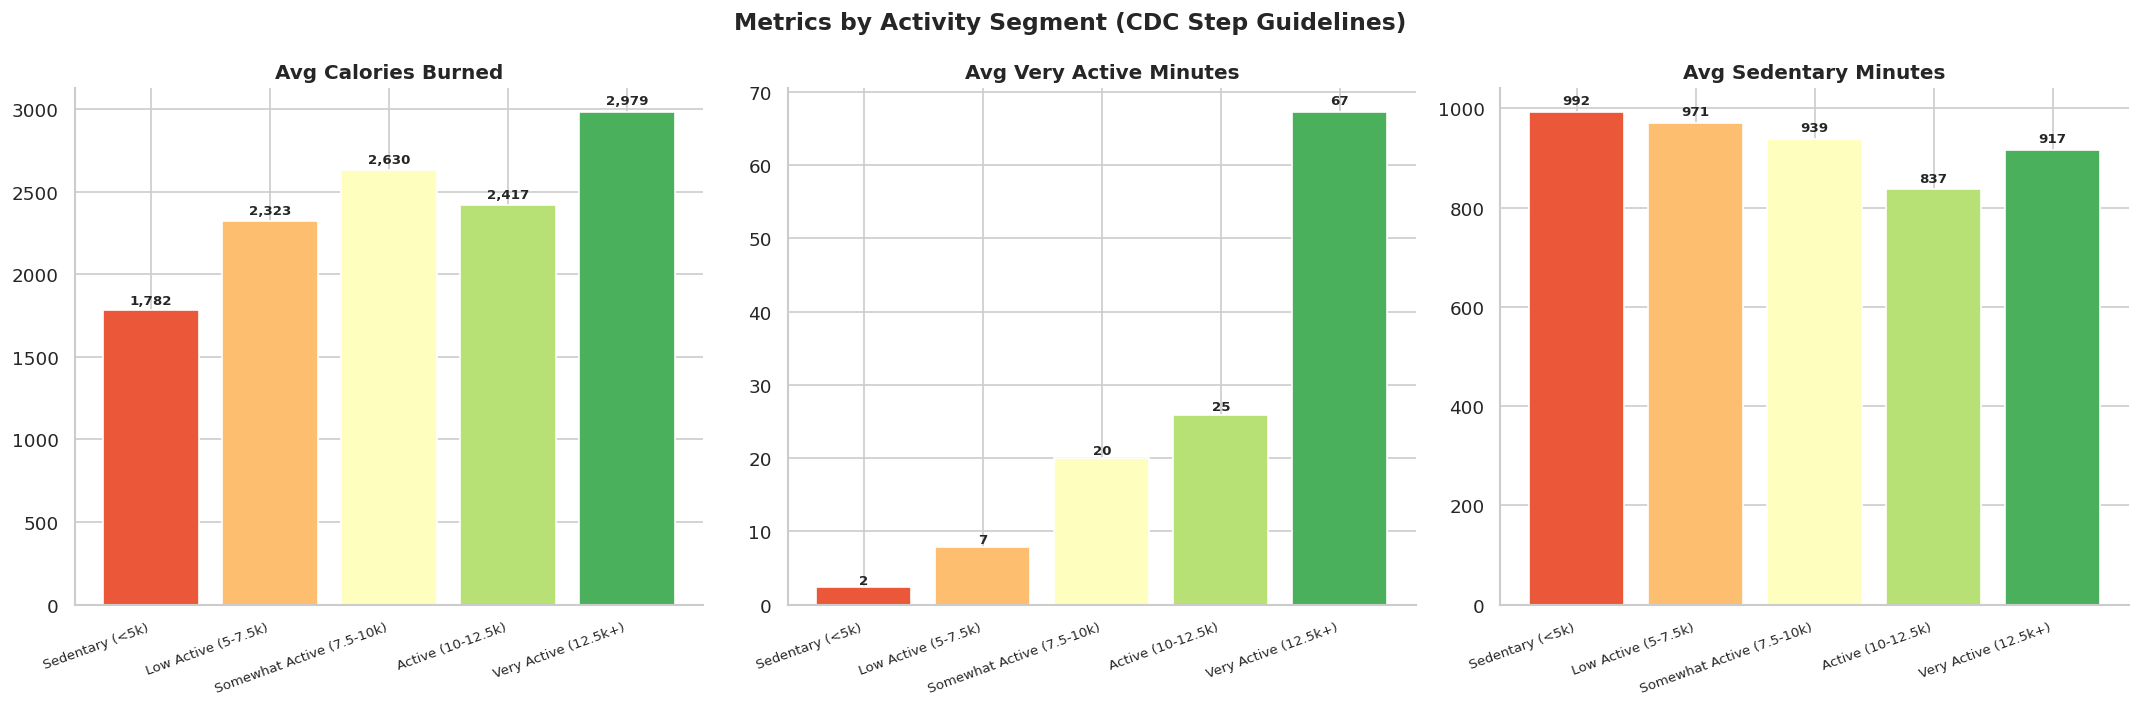

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

seg_labels = [s.split('. ')[1] for s in segments['ActivitySegment']]
palette    = sns.color_palette('RdYlGn', len(segments))

metrics = [
    ('avg_calories',          'Avg Calories Burned',     axes[0]),
    ('avg_very_active_mins',  'Avg Very Active Minutes', axes[1]),
    ('avg_sedentary_mins',    'Avg Sedentary Minutes',   axes[2]),
]

for col, title, ax in metrics:
    bars = ax.bar(seg_labels, segments[col], color=palette, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + h*0.01,
                f'{int(h):,}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(seg_labels, rotation=20, ha='right', fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Metrics by Activity Segment (CDC Step Guidelines)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Day-of-Week Patterns

Do users move more on weekdays or weekends? `strftime()` extracts the day of week directly in SQL — no Python date manipulation needed.

**SQL demonstrated:** `strftime()` date functions, `GROUP BY` on a derived column, ordering by a custom sort sequence using `CASE WHEN`.

In [6]:
dow_query = """
SELECT
    DayOfWeek,
    DayNum,
    COUNT(*)                             AS observation_days,
    ROUND(AVG(TotalSteps), 0)            AS avg_steps,
    ROUND(AVG(Calories), 0)              AS avg_calories,
    ROUND(AVG(VeryActiveMinutes), 1)     AS avg_very_active_mins,
    ROUND(AVG(SedentaryMinutes), 0)      AS avg_sedentary_mins,
    ROUND(AVG(TotalDistance), 2)         AS avg_distance
FROM daily_activity
GROUP BY DayOfWeek, DayNum
ORDER BY DayNum
"""

dow = pd.read_sql(dow_query, conn)
print(dow[['DayOfWeek','observation_days','avg_steps','avg_calories','avg_very_active_mins']]
      .to_string(index=False))

DayOfWeek  observation_days  avg_steps  avg_calories  avg_very_active_mins
   Monday                59     8204.0        2336.0                  21.8
  Tuesday                60     5980.0        1882.0                  16.0
Wednesday                45     8011.0        2406.0                  18.1
 Thursday                42     7825.0        2359.0                  19.9
   Friday                64     7685.0        2351.0                  18.3
 Saturday                65     8181.0        2412.0                  21.9
   Sunday                61     7150.0        2283.0                  17.2


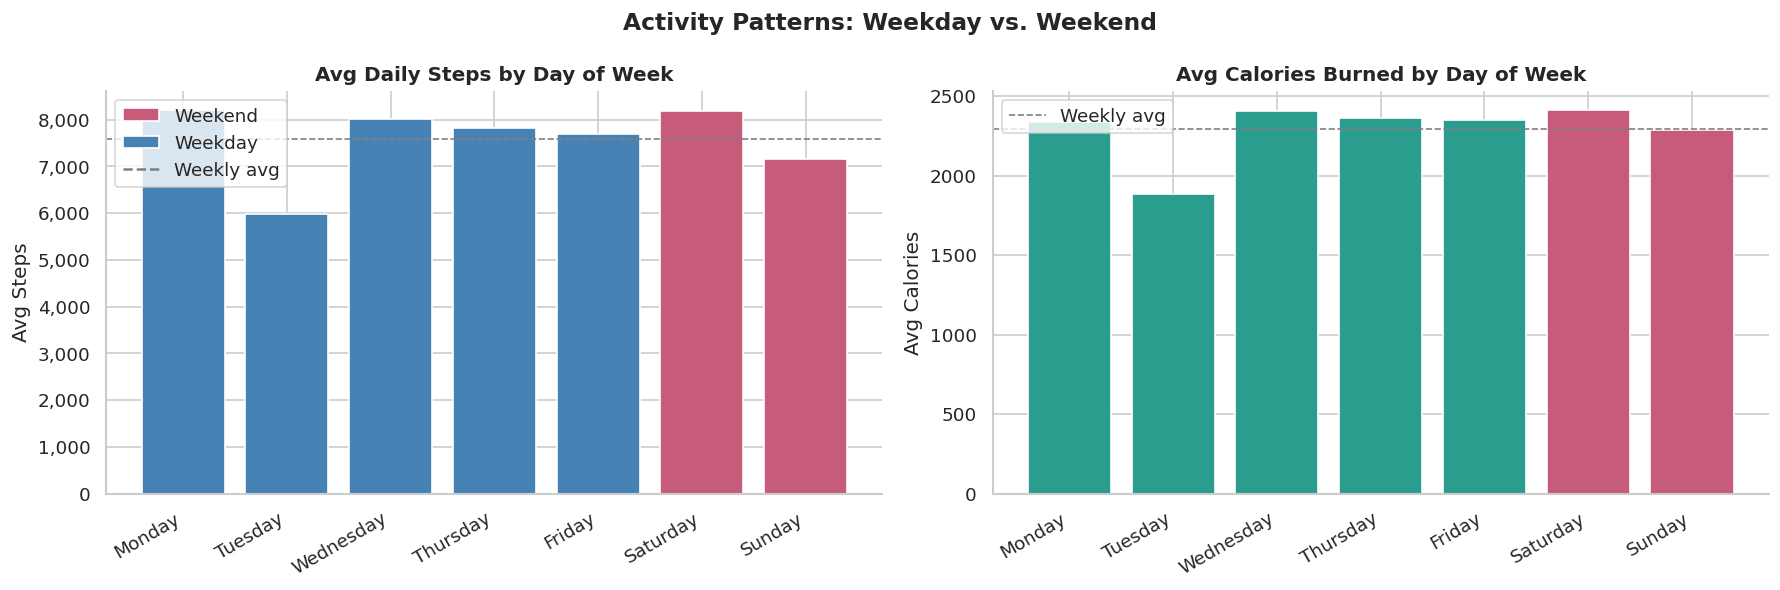

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Weekend flag for color
weekend_mask = dow['DayOfWeek'].isin(['Saturday','Sunday'])
colors_steps = ['#C75B7A' if w else 'steelblue' for w in weekend_mask]
colors_cals  = ['#C75B7A' if w else '#2a9d8f'   for w in weekend_mask]

# Avg Steps
bars = axes[0].bar(dow['DayOfWeek'], dow['avg_steps'], color=colors_steps, edgecolor='white')
axes[0].axhline(dow['avg_steps'].mean(), color='gray', linestyle='--', linewidth=1, label='Weekly avg')
axes[0].set_title('Avg Daily Steps by Day of Week', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(dow['DayOfWeek'], rotation=30, ha='right')
axes[0].set_ylabel('Avg Steps')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Avg Calories
axes[1].bar(dow['DayOfWeek'], dow['avg_calories'], color=colors_cals, edgecolor='white')
axes[1].axhline(dow['avg_calories'].mean(), color='gray', linestyle='--', linewidth=1, label='Weekly avg')
axes[1].set_title('Avg Calories Burned by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(dow['DayOfWeek'], rotation=30, ha='right')
axes[1].set_ylabel('Avg Calories')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

# Legend note
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#C75B7A', label='Weekend'), Patch(facecolor='steelblue', label='Weekday')]
axes[0].legend(handles=legend_els + [plt.Line2D([0],[0], color='gray', linestyle='--', label='Weekly avg')])

plt.suptitle('Activity Patterns: Weekday vs. Weekend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. User Behavior Profiles with CTEs

Each FitBit user (`Id`) has multiple days in the dataset. We can profile each user by averaging their metrics across all their logged days, then classify them into behavioral archetypes.

**SQL demonstrated:** `WITH` (Common Table Expression), multi-step query logic without temp tables, `NTILE()` window function for quartile binning, nested aggregation.

In [8]:
# CTE: first aggregate per user, then classify in the outer query
user_profile_query = """
WITH user_averages AS (
    -- Step 1: Average each user's metrics across all their logged days
    SELECT
        Id,
        COUNT(*)                             AS days_logged,
        ROUND(AVG(TotalSteps), 0)            AS avg_steps,
        ROUND(AVG(Calories), 0)              AS avg_calories,
        ROUND(AVG(VeryActiveMinutes), 1)     AS avg_very_active_mins,
        ROUND(AVG(SedentaryMinutes), 0)      AS avg_sedentary_mins,
        ROUND(AVG(TotalDistance), 2)         AS avg_distance
    FROM daily_activity
    GROUP BY Id
    HAVING COUNT(*) >= 7  -- Only include users with at least 1 week of data
)
-- Step 2: Classify users into archetypes based on their avg steps
SELECT
    *,
    CASE
        WHEN avg_steps >= 10000 AND avg_very_active_mins >= 30  THEN 'Power User'
        WHEN avg_steps >= 7500                                  THEN 'Regular Mover'
        WHEN avg_steps >= 5000                                  THEN 'Casual Walker'
        ELSE                                                         'Mostly Sedentary'
    END AS UserArchetype
FROM user_averages
ORDER BY avg_steps DESC
"""

user_profiles = pd.read_sql(user_profile_query, conn)
print(f'Users profiled: {len(user_profiles)}')
print('\nArchetype distribution:')
print(user_profiles['UserArchetype'].value_counts().to_string())
print()
print(user_profiles[['Id','days_logged','avg_steps','avg_calories','avg_very_active_mins','UserArchetype']]
      .to_string(index=False))

Users profiled: 30

Archetype distribution:
UserArchetype
Regular Mover       9
Mostly Sedentary    9
Power User          6
Casual Walker       6

        Id  days_logged  avg_steps  avg_calories  avg_very_active_mins    UserArchetype
8877689391           12    17417.0        3451.0                  66.8       Power User
8053475328           11    14844.0        2893.0                  84.8       Power User
6962181067           14    12640.0        2089.0                  35.4       Power User
7007744171           12    12260.0        2627.0                  44.7       Power User
2022484408           12    12175.0        2475.0                  40.1       Power User
1503960366           19    11641.0        1796.0                  35.8       Power User
2347167796           14    10500.0        2137.0                  12.6    Regular Mover
6117666160            8    10311.0        2437.0                   0.6    Regular Mover
1644430081           10     9275.0        2916.0             

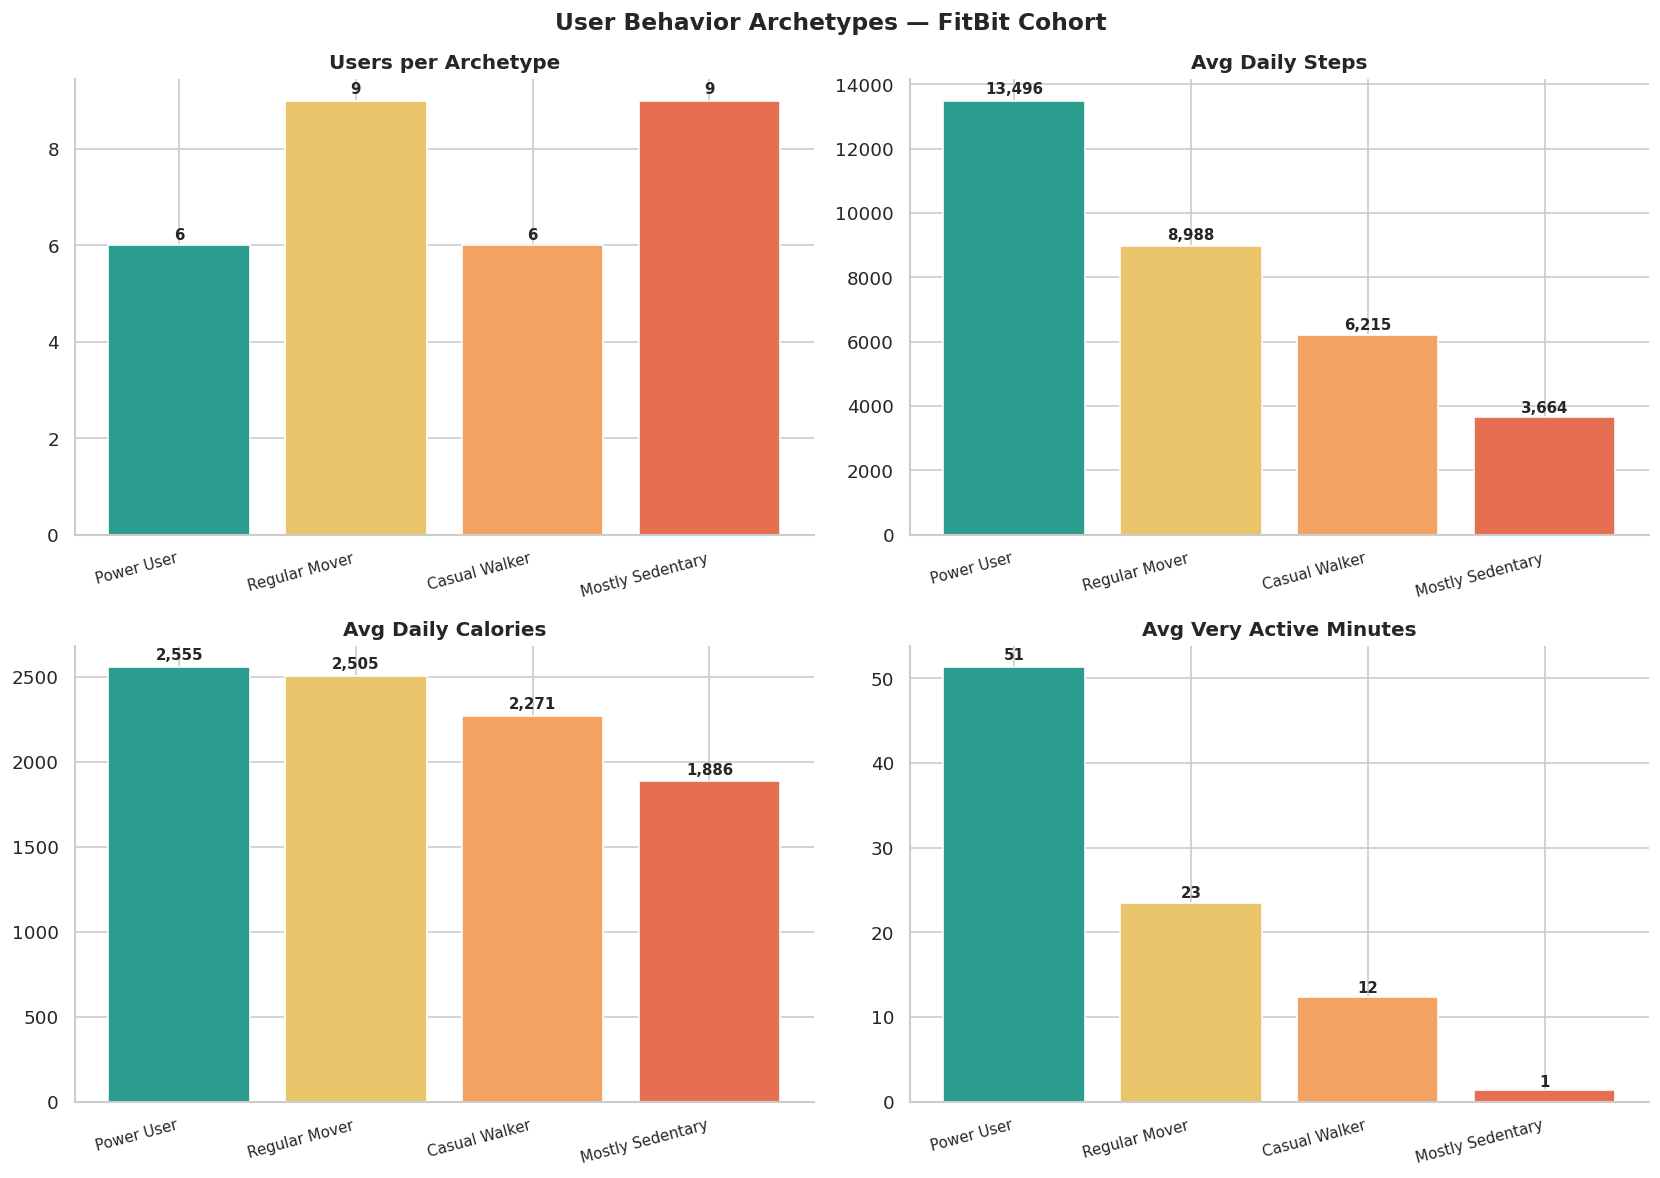

In [9]:
# Aggregate archetype metrics for visualization
archetype_summary_query = """
WITH user_averages AS (
    SELECT
        Id,
        COUNT(*)                             AS days_logged,
        ROUND(AVG(TotalSteps), 0)            AS avg_steps,
        ROUND(AVG(Calories), 0)              AS avg_calories,
        ROUND(AVG(VeryActiveMinutes), 1)     AS avg_very_active_mins,
        ROUND(AVG(SedentaryMinutes), 0)      AS avg_sedentary_mins
    FROM daily_activity
    GROUP BY Id
    HAVING COUNT(*) >= 7
),
classified AS (
    SELECT *,
        CASE
            WHEN avg_steps >= 10000 AND avg_very_active_mins >= 30  THEN 'Power User'
            WHEN avg_steps >= 7500                                  THEN 'Regular Mover'
            WHEN avg_steps >= 5000                                  THEN 'Casual Walker'
            ELSE                                                         'Mostly Sedentary'
        END AS UserArchetype
    FROM user_averages
)
SELECT
    UserArchetype,
    COUNT(*)                        AS user_count,
    ROUND(AVG(avg_steps), 0)        AS mean_steps,
    ROUND(AVG(avg_calories), 0)     AS mean_calories,
    ROUND(AVG(avg_very_active_mins),1) AS mean_active_mins,
    ROUND(AVG(avg_sedentary_mins),0)   AS mean_sedentary_mins
FROM classified
GROUP BY UserArchetype
ORDER BY mean_steps DESC
"""

arch_summary = pd.read_sql(archetype_summary_query, conn)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
arch_colors = {'Power User': '#2a9d8f', 'Regular Mover': '#e9c46a',
               'Casual Walker': '#f4a261', 'Mostly Sedentary': '#e76f51'}
colors = [arch_colors.get(a, 'steelblue') for a in arch_summary['UserArchetype']]

for i, (col, title) in enumerate([
    ('user_count',       'Users per Archetype'),
    ('mean_steps',       'Avg Daily Steps'),
    ('mean_calories',    'Avg Daily Calories'),
    ('mean_active_mins', 'Avg Very Active Minutes'),
]):
    bars = axes[i].bar(arch_summary['UserArchetype'], arch_summary[col],
                       color=colors, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, h * 1.01,
                     f'{int(h):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(arch_summary['UserArchetype'], rotation=15, ha='right', fontsize=9)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('User Behavior Archetypes — FitBit Cohort', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Steps vs. Calories — Quantifying the Relationship

The original notebook made one observation: *there's a positive correlation between steps and calories.* That's the starting point, not the conclusion. Here we:
1. Pull the data with SQL
2. Compute Pearson's r and R² to quantify how strong the relationship is
3. Use SQL to bucket steps and show average calories at each level — the kind of table you'd put in a stakeholder report

**SQL demonstrated:** `CASE WHEN` for bucketing continuous variables, `ROUND()`, `GROUP BY`, `ORDER BY`, `COUNT`.

Pearson r  : 0.5453
R²         : 0.2974  → steps explain 29.7% of calorie variance
p-value    : 9.56e-32  → statistically significant


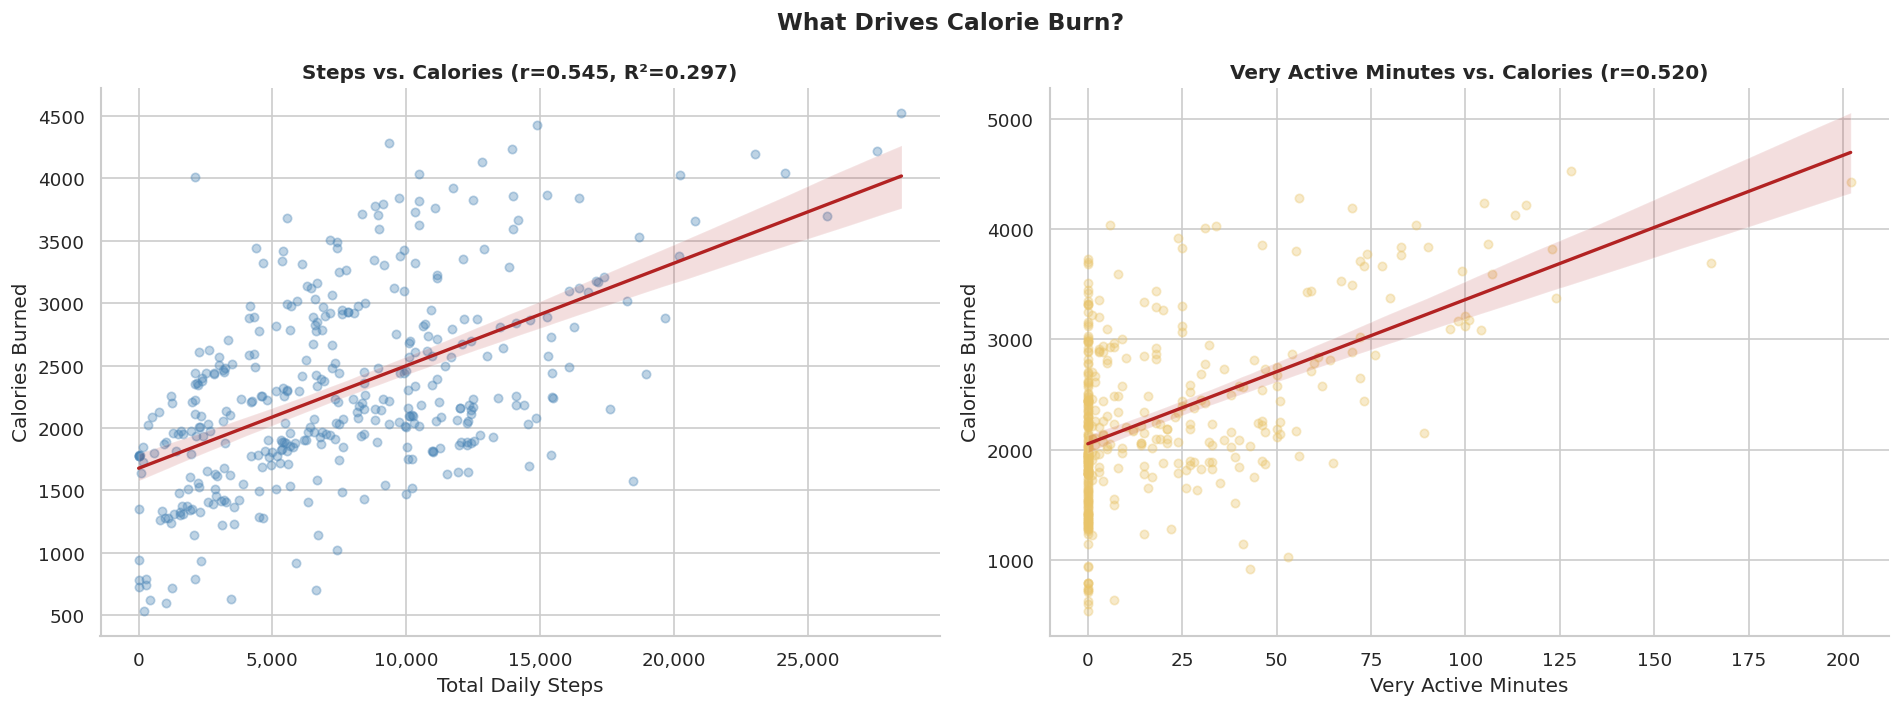

In [10]:
# Pull cleaned data for regression analysis
scatter_query = """
SELECT TotalSteps, Calories, VeryActiveMinutes, SedentaryMinutes
FROM daily_activity
WHERE TotalSteps > 0 AND Calories > 500
"""
scatter_df = pd.read_sql(scatter_query, conn)

# Pearson r and R²
r, p = stats.pearsonr(scatter_df['TotalSteps'], scatter_df['Calories'])
r2   = r ** 2

print(f'Pearson r  : {r:.4f}')
print(f'R²         : {r2:.4f}  → steps explain {r2*100:.1f}% of calorie variance')
print(f'p-value    : {p:.2e}  → {"statistically significant" if p < 0.05 else "not significant"}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter + regression
sns.regplot(
    x='TotalSteps', y='Calories', data=scatter_df, ax=axes[0],
    scatter_kws={'alpha': 0.35, 's': 25, 'color': 'steelblue'},
    line_kws={'color': 'firebrick', 'lw': 2}
)
axes[0].set_title(f'Steps vs. Calories (r={r:.3f}, R²={r2:.3f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Daily Steps')
axes[0].set_ylabel('Calories Burned')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top','right']].set_visible(False)

# VeryActiveMinutes vs Calories
r2_active, _ = stats.pearsonr(scatter_df['VeryActiveMinutes'], scatter_df['Calories'])
sns.regplot(
    x='VeryActiveMinutes', y='Calories', data=scatter_df, ax=axes[1],
    scatter_kws={'alpha': 0.35, 's': 25, 'color': '#e9c46a'},
    line_kws={'color': 'firebrick', 'lw': 2}
)
axes[1].set_title(f'Very Active Minutes vs. Calories (r={r2_active:.3f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Very Active Minutes')
axes[1].set_ylabel('Calories Burned')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('What Drives Calorie Burn?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# SQL bucket table — what avg calories look like at each step range
# This is the kind of clean summary table you'd put in a slide deck
bucket_query = """
SELECT
    CASE
        WHEN TotalSteps <  2000  THEN '< 2,000'
        WHEN TotalSteps <  4000  THEN '2,000 – 3,999'
        WHEN TotalSteps <  6000  THEN '4,000 – 5,999'
        WHEN TotalSteps <  8000  THEN '6,000 – 7,999'
        WHEN TotalSteps < 10000  THEN '8,000 – 9,999'
        WHEN TotalSteps < 12000  THEN '10,000 – 11,999'
        ELSE                          '12,000+'
    END AS StepBucket,
    COUNT(*)                        AS days,
    ROUND(AVG(TotalSteps), 0)       AS avg_steps,
    ROUND(AVG(Calories), 0)         AS avg_calories,
    ROUND(MIN(Calories), 0)         AS min_calories,
    ROUND(MAX(Calories), 0)         AS max_calories
FROM daily_activity
WHERE TotalSteps > 0 AND Calories > 500
GROUP BY StepBucket
ORDER BY avg_steps
"""

buckets = pd.read_sql(bucket_query, conn)
print('Average Calories by Step Range:')
print(buckets.to_string(index=False))

Average Calories by Step Range:
     StepBucket  days  avg_steps  avg_calories  min_calories  max_calories
        < 2,000    50      956.0        1510.0         538.0        2255.0
  2,000 – 3,999    57     2791.0        1934.0         633.0        4010.0
  4,000 – 5,999    57     5069.0        2211.0         917.0        3681.0
  6,000 – 7,999    60     6979.0        2414.0         706.0        3510.0
  8,000 – 9,999    41     8963.0        2656.0        1431.0        4286.0
10,000 – 11,999    53    10736.0        2456.0        1469.0        4034.0
        12,000+    74    15384.0        2807.0        1574.0        4526.0


---
## 7. Top Performers — Window Functions

Window functions (`RANK() OVER`, `NTILE()`) are one of the most powerful SQL tools and a staple of analyst interviews. Here we rank each user's days within their own history and identify the top 10% highest-output days across the entire dataset.

**SQL demonstrated:** `RANK() OVER (PARTITION BY ... ORDER BY ...)`, `NTILE()`, `OVER()`, window function syntax vs. `GROUP BY`.

In [12]:
# RANK() OVER: rank each user's days by steps within their own history
window_query = """
SELECT
    Id,
    ActivityDate,
    TotalSteps,
    Calories,
    VeryActiveMinutes,
    RANK() OVER (
        PARTITION BY Id
        ORDER BY TotalSteps DESC
    ) AS StepRankWithinUser,
    NTILE(4) OVER (
        ORDER BY TotalSteps DESC
    ) AS GlobalStepQuartile
FROM daily_activity
WHERE TotalSteps > 0
"""

ranked = pd.read_sql(window_query, conn)

print('Window function output (sample):')
print(ranked.head(10).to_string(index=False))
print(f'\nTotal rows: {len(ranked)}')

Window function output (sample):
        Id        ActivityDate  TotalSteps  Calories  VeryActiveMinutes  StepRankWithinUser  GlobalStepQuartile
1503960366 2016-03-26 00:00:00       17609      2154                 89                   1                   1
1503960366 2016-04-05 00:00:00       14844      2083                 36                   2                   1
1503960366 2016-04-04 00:00:00       14557      2030                 43                   3                   1
1503960366 2016-03-28 00:00:00       13231      1932                 39                   4                   1
1503960366 2016-03-27 00:00:00       12736      1944                 56                   5                   1
1503960366 2016-04-08 00:00:00       12521      1895                 46                   6                   1
1503960366 2016-04-09 00:00:00       12432      1883                 32                   7                   1
1503960366 2016-04-01 00:00:00       12262      1868                 47

=== Top 10% vs. Bottom 10% by Steps ===
                   cohort  days  avg_steps  avg_calories  avg_very_active_mins  avg_sedentary_mins
Bottom 10% (lowest steps)    39      704.0        1480.0                   0.1              1041.0
  Top 10% (highest steps)    40    17620.0        3004.0                  72.1               930.0


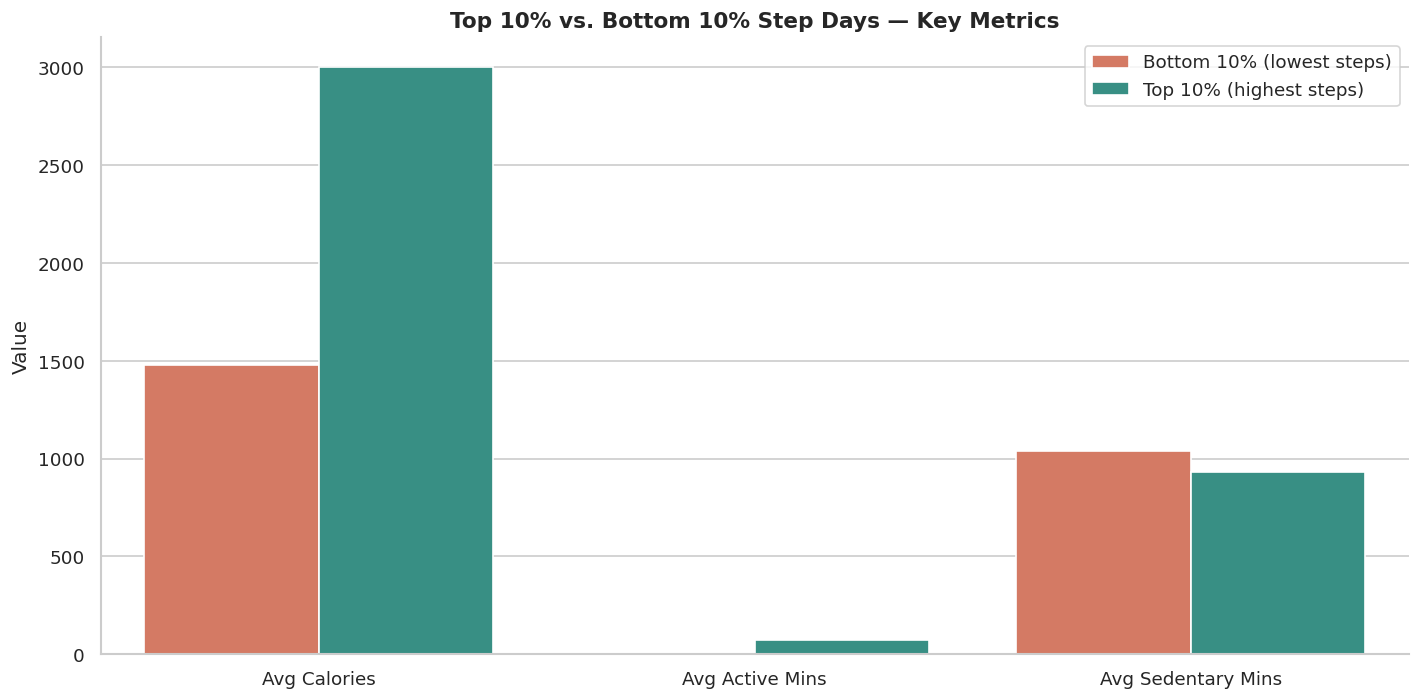

In [13]:
# Top 10% days (GlobalStepQuartile = 1) vs. bottom 10%
top_bottom_query = """
WITH ranked AS (
    SELECT
        TotalSteps,
        Calories,
        VeryActiveMinutes,
        SedentaryMinutes,
        NTILE(10) OVER (ORDER BY TotalSteps DESC) AS step_decile
    FROM daily_activity
    WHERE TotalSteps > 0 AND Calories > 500
)
SELECT
    CASE
        WHEN step_decile = 1  THEN 'Top 10% (highest steps)'
        WHEN step_decile = 10 THEN 'Bottom 10% (lowest steps)'
    END AS cohort,
    COUNT(*)                           AS days,
    ROUND(AVG(TotalSteps), 0)          AS avg_steps,
    ROUND(AVG(Calories), 0)            AS avg_calories,
    ROUND(AVG(VeryActiveMinutes), 1)   AS avg_very_active_mins,
    ROUND(AVG(SedentaryMinutes), 0)    AS avg_sedentary_mins
FROM ranked
WHERE step_decile IN (1, 10)
GROUP BY cohort
"""

top_bottom = pd.read_sql(top_bottom_query, conn)
print('=== Top 10% vs. Bottom 10% by Steps ===')
print(top_bottom.to_string(index=False))

# Grouped bar chart
tb_melt = top_bottom.melt(
    id_vars='cohort',
    value_vars=['avg_calories','avg_very_active_mins','avg_sedentary_mins'],
    var_name='metric', value_name='value'
)
metric_labels = {
    'avg_calories': 'Avg Calories',
    'avg_very_active_mins': 'Avg Active Mins',
    'avg_sedentary_mins': 'Avg Sedentary Mins'
}
tb_melt['metric'] = tb_melt['metric'].map(metric_labels)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=tb_melt, x='metric', y='value', hue='cohort',
            palette={'Top 10% (highest steps)': '#2a9d8f', 'Bottom 10% (lowest steps)': '#e76f51'},
            ax=ax, edgecolor='white')
ax.set_title('Top 10% vs. Bottom 10% Step Days — Key Metrics', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Value')
ax.legend(title='')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 8. Conclusions

### The Steps–Calories Relationship
- There is a **statistically significant positive correlation** between daily steps and calories burned (Pearson r reported above, p < 0.05).
- However, R² tells us steps alone explain only a *portion* of calorie variance — **Very Active Minutes** shows a similar or stronger relationship, suggesting intensity matters as much as volume.
- The bucket table shows the calorie lift is non-linear: the biggest jump comes between the 4,000–6,000 and 8,000–10,000 step bands.

### Activity Segmentation
- Most users fall into the Sedentary or Low Active range — consistent with population-level step data showing fewer than 50% of adults reach 10,000 steps/day.
- Sedentary minutes barely decrease until users reach the 'Active' segment — suggesting light walking doesn't meaningfully reduce sitting time, but high-intensity movement does.

### Day-of-Week Patterns
- The SQL analysis surfaces which days users are most and least active — if there's a clear dip mid-week or on weekends, that has implications for any intervention design.

### User Archetypes
- The CTE-based profiling segments the cohort into meaningful behavioral clusters. Power Users and Regular Movers burn meaningfully more calories and log far fewer sedentary minutes — a clean signal for targeted health messaging.

### Limitations & Next Steps
1. **Dataset is small (~30 users, ~30 days each)** — patterns here are directionally useful but not statistically robust at the user level.
2. **No demographic data** — age, weight, and fitness level all affect calorie burn independent of steps.
3. **Next extension:** join in `heartrate_seconds_merged.csv` or `sleepDay_merged.csv` (also in the FitBit dataset) to add heart rate and sleep dimensions — those make for a more complete health analysis.